In [ ]:
#BiLSTM ko cân bằng
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

print("="*75)
print("🚀 KHỞI ĐỘNG PIPELINE: BiLSTM BASELINE (ĐỒNG BỘ TIME-SPLIT & SMART SCALE)")
print("="*75)

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & LỌC ĐẶC TRƯNG GỐC 
# ==============================================================================
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# Sort chuẩn theo User và Thời gian
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

# Xác định danh sách feature (Bỏ qua các cột định danh)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
drop_cols_leakage = [
    # leakf
    'http_n_leakf',
    'http_leakf_mean_url_len',
    'http_leakf_mean_url_depth',
    'http_leakf_mean_http_c_len',
    'http_leakf_mean_http_c_nwords',

    # hackf
    'http_n_hackf',
    'http_hackf_mean_url_len',
    'http_hackf_mean_url_depth',
    'http_hackf_mean_http_c_len',
    'http_hackf_mean_http_c_nwords',
]
# drop_cols_suspect = [
#     # phof (gần như chỉ class 2)
#     'file_n_phof',
#     'file_phof_mean_file_len',
#     'file_phof_mean_file_nwords',
#     'file_phof_n-disk0',
#     'file_phof_n-disk1',
#     'file_phof_n-disk2',

#     # cloudf (bias class 0 & 2)
#     'http_n_cloudf',
#     'http_cloudf_mean_url_len',
#     'http_cloudf_mean_url_depth',
#     'http_cloudf_mean_http_c_len',
#     'http_cloudf_mean_http_c_nwords',
# ]
# drop_cols_optional = [
#     'file_compf_n-disk1',
#     'file_compf_n-disk2',
#     'file_txtf_n-disk1',
#     'file_txtf_n-disk2',
#     'file_exef_n-disk1',
#     'file_exef_n-disk2',
# ]
feature_cols = [col for col in df.columns if col not in (exclude_cols + drop_cols_leakage)]

# ==============================================================================
# 2. TIME + USER SPLIT 
# ==============================================================================
def split_user_time_multiclass(df, label_col='insider'):
    print("\n SPLIT USER + TIME")
    # ------------------------------------------------------------------
    # 1. SORT TIME
    # ------------------------------------------------------------------
    df = df.sort_values(by='starttime').reset_index(drop=True)
    n = len(df)
    test_idx = int(n * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    print(f"  -> Past: {len(df_past):,} | Future (Test): {len(df_future):,}")
    # ------------------------------------------------------------------
    # 2. LOẠI INSIDER TRONG FUTURE
    # ------------------------------------------------------------------
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    print(f"  -> Loại {len(known_insiders)} insider đã xuất hiện trong train khỏi TEST")
    # ------------------------------------------------------------------
    # 3. SPLIT TRAIN / VAL (TRONG PAST)
    # ------------------------------------------------------------------
    n_past = len(df_past)
    val_idx = int(n_past * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    # ------------------------------------------------------------------
    # 4. SORT LẠI THEO USER + TIME
    # ------------------------------------------------------------------
    df_train = df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_val   = df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_test  = df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    # ------------------------------------------------------------------
    # 5. REPORT
    # ------------------------------------------------------------------
    print("\n📊 DATA REPORT")
    print("-" * 50)
    print(f"TRAIN: {len(df_train):,} samples | {df_train['user'].nunique()} users")
    print(df_train[label_col].value_counts())
    print(f"\nVAL: {len(df_val):,} samples | {df_val['user'].nunique()} users")
    print(df_val[label_col].value_counts())
    print(f"\nTEST: {len(df_test):,} samples | {df_test['user'].nunique()} users")
    print(df_test[label_col].value_counts())
    print("-" * 50)
    return df_train, df_val, df_test
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# ==============================================================================
# 2️⃣ XÓA CỘT ZERO VARIANCE (DỌN RÁC)
# ==============================================================================
print("\n Đang dọn dẹp các cột Zero Variance...")

# Tìm các cột không thay đổi giá trị trên tập Train
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
print(f" -> Đã tìm thấy {len(dead_cols)} cột variance = 0.")

for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')

# Cập nhật lại danh sách feature hợp lệ (Vẫn giữ đúng thứ tự cột ban đầu)
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI & SCALING CÓ CHỌN LỌC
# ==============================================================================
print("\nĐang phân loại và Scale các cột Numeric...")

categorical_cols = [
    'pc', 'start_with', 'end_with', 'ses_start', 'ses_end',
    'role', 'f_unit', 'dept', 'team', 'ITAdmin',
]
# Đảm bảo các cột đang tồn tại trong data
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]

# Các cột còn lại sẽ Scale
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

print(f" -> {len(cat_cols_to_keep)} cột Categorical.")
print(f" -> {len(num_cols_to_scale)} cột Numeric.")

scaler = StandardScaler()

# Chỉ Scale đúng nhóm num_cols_to_scale
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW (Cho Deep Learning)
# ==============================================================================
print("\n[4/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM (Window_size = 3)...")

def create_sliding_windows_3D(df_subset, window_size=3):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size] 
            #window_label = labels[i + window_size - 1]
            window_label = np.max(labels[i : i + window_size])
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)

# --- BÁO CÁO KIỂM TOÁN (AUDIT REPORT) 2: SHAPE 3D & PHÂN BỔ NHÃN SAU WINDOW ---
print("\n" + "-"*60)
print("📦 BÁO CÁO KIỂM TOÁN TENSOR 3D (SAU SLIDING WINDOW)")
print("-"*60)
print(f"Tập TRAIN Tensor: {X_train.shape}")
print(f"  > Giải thích: {X_train.shape[0]:,} (Mẫu) x {X_train.shape[1]} (Time steps) x {X_train.shape[2]} (Đặc trưng gốc/bước)")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_train, return_counts=True)))}")

print(f"\nTập VAL Tensor: {X_val.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_val, return_counts=True)))}")

print(f"\nTập TEST Tensor: {X_test.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_test, return_counts=True)))}")
print("-"*60)

#del df_train, df_val, df_test; gc.collect()

# ==============================================================================
# 5️⃣ XÂY DỰNG KIẾN TRÚC & HUẤN LUYỆN BiLSTM (CÓ CLASS WEIGHT)
# ==============================================================================
print("\n[5/5] Đang lắp ráp & Huấn luyện mạng BiLSTM...")
custom_weight = {
    0: 1.0,
    1: 10.0,
    2: 50.0,
    3: 20.0
}

T = X_train.shape[1] # Time steps (3)
F = X_train.shape[2] # Features (120)

model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
    Dropout(0.4),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(4, activation='softmax') 
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, 
    batch_size=2048,
    class_weight=custom_weight,
    callbacks=[early_stopping, rlr], 
    verbose=1
)
train_time = time.time() - start_time
print(f"✅ Huấn luyện BiLSTM hoàn tất! Thời gian: {int(train_time // 60)} phút {train_time % 60:.2f} giây")

# ==============================================================================
# 🔴 ĐÁNH GIÁ & VẼ BIỂU ĐỒ
# ==============================================================================
print("\n" + "="*60)
print("📊 BÁO CÁO BiLSTM BASELINE")
print("="*60)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print(classification_report(y_test, y_pred, target_names=classes_names, digits=4, zero_division=0))

# --- Vẽ biểu đồ Loss & Acc ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BiLSTM BASELINE (ĐỒNG BỘ TIỀN XỬ LÝ)', fontsize=16, fontweight='bold', y=1.05)

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Biểu đồ Loss')
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history.history['accuracy'], label='Train Acc', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='orange')
axes[1].set_title('Biểu đồ Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- Vẽ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - BiLSTM', fontweight='bold', pad=15)
plt.show()

In [ ]:
#BiLSTM Cân Bằng RUS+SMOTE (Tích hợp AUC & Vẽ biểu đồ 3 trục)
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
import time
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy, BinaryFocalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

# 🔒 HÀM CỐ ĐỊNH SEED BẮT BUỘC ĐỂ KẾT QUẢ KHÔNG NHẢY MÚA
def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()
    print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

set_all_seeds(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ (GIỮ NGUYÊN NHƯ CỦA BẠN)
# ==============================================================================
print("\n[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']

feature_cols = [col for col in df.columns if col not in (exclude_cols)]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))
    
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# XÓA CỘT ZERO VARIANCE
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI (FREQUENCY SMOOTHING) & SCALE CHỌN LỌC
# ==============================================================================
print("\n[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...")

categorical_cols = ['pc', 'start_with', 'end_with', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# 1. ÁP DỤNG FREQUENCY ENCODING (CÓ BƠM ĐÁY SMOOTHING)
for col in cat_cols_to_keep:
    # Lập từ điển đếm tỷ lệ % xuất hiện trên tập TRAIN
    freq_map_raw = df_train[col].value_counts(normalize=True).to_dict()
    # 🔴 BÍ KÍP CỦA BẠN: Ép đáy 1% (0.01) để chống rỗ ranh giới cho các giá trị cực hiếm
    freq_map = {k: max(v, 0.01) for k, v in freq_map_raw.items()}
    # Map tỷ lệ lên các tập. Nếu Test có giá trị lạ hoắc, gán = 0.01 (Mức đáy) thay vì 0
    df_train[col] = df_train[col].map(freq_map).fillna(0.01)
    df_val[col]   = df_val[col].map(freq_map).fillna(0.01)
    df_test[col]  = df_test[col].map(freq_map).fillna(0.01)

# 2. SCALE TOÀN BỘ DỮ LIỆU (NHƯNG BỎ CATEGORICAL RA)
# 🔴 BÍ KÍP CỦA BẠN: Giữ nguyên Categorical trong dải [0.01, 1.0], CHỈ Scale Numeric!
scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# Lúc này feature_cols vẫn giữ nguyên trật tự, chỉ là giá trị bên trong đã được tối ưu
print(f" -> Đã ép {len(cat_cols_to_keep)} cột Categorical thành Tần suất (Có Smoothing đáy 1%).")
print(f" -> Đã Scale chuẩn hóa {len(num_cols_to_scale)} cột Numeric.")
print(f" -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: {len(feature_cols)} (Hoàn hảo!)")

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW 
# ==============================================================================
print("\n[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...")

# def create_sliding_windows_3D(df_subset, window_size=5):
#     df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
#     X_list, y_list = [], []
#     for user, group in tqdm(df_subset.groupby('user'), leave=False):
#         if len(group) < window_size: continue
#         features, labels = group[feature_cols].values, group['insider'].values
#         for i in range(len(group) - window_size + 1):
#             X_list.append(features[i : i + window_size])
#             y_list.append(np.max(labels[i : i + window_size]))
#     return np.array(X_list), np.array(y_list)

# WINDOW_SIZE = 5
# X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
# X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
# X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)
def create_sliding_windows_3D(df_subset, window_size=5, step=1):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        
        # 🔴 BÍ KÍP Ở ĐÂY: Thêm 'step' vào vòng lặp range
        for i in range(0, len(group) - window_size + 1, step):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
            #y_list.append((labels[i + window_size - 1]))
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
# 🔴 TẬP TRAIN: Ép nhảy 2 bước (hoặc 3) để giảm Overlap, chống học vẹt!
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1) 
# 🔴 TẬP VAL & TEST: Vẫn giữ step=1 để khám nghiệm không bỏ sót bất kỳ giây phút nào!
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1)

# ==============================================================================
# 🟢 PHẦN 1: MÔ HÌNH CHÍNH (MAIN MODEL BiLSTM - 4 LỚP)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)")
print("="*75)

N_train, T, F = X_train.shape
X_train_flat = X_train.reshape(N_train, T * F)

rus = RandomUnderSampler(sampling_strategy={0: 15000}, random_state=42)
X_res_flat, y_res = rus.fit_resample(X_train_flat, y_train)

smote_main = SMOTE(sampling_strategy={1: 10000, 2: 10000, 3: 10000}, random_state=42, k_neighbors=2)
X_main_flat, y_main_bal = smote_main.fit_resample(X_res_flat, y_res)

X_train_main = X_main_flat.reshape(-1, T, F)
# ====================================================================
# 🔴 BÍ KÍP CẤP CỨU CỘT CATEGORICAL SAU KHI SMOTE
# ====================================================================
print("-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...")

# Lấy index của các cột không bị scale
cat_indices = [feature_cols.index(col) for col in cat_cols_to_keep]

# Ép kiểu (Làm tròn số thập phân về lại số nguyên chuẩn)
for idx in cat_indices:
    # Round (làm tròn gần nhất) và ép về float/int để tránh lỗi shape
    X_train_main[:, :, idx] = np.round(X_train_main[:, :, idx])

print("✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!")
# 🔴 BÍ KÍP: CHUYỂN NHÃN SANG ONE-HOT ĐỂ TÍNH ĐƯỢC AUC ĐA LỚP
y_main_bal_onehot = tf.keras.utils.to_categorical(y_main_bal, num_classes=4)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

start_time_t1 = time.time()
model_main = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(4, activation='softmax')
])
focal_loss_t1 = CategoricalFocalCrossentropy(
    gamma=2.0, 
    #alpha=[0.05, 0.15, 0.35, 0.25] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
)

model_main.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=focal_loss_t1, # 🔴 THAY CROSS-ENTROPY BẰNG FOCAL LOSS TẠI ĐÂY
    metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
)
# 🔴 ĐỔI LOSS SANG CATEGORICAL VÀ THÊM METRIC AUC
# model_main.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
# )

es_main = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# es_main = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# rlr_main = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)

history_main = model_main.fit(
    X_train_main, y_main_bal_onehot, 
    validation_data=(X_val, y_val_onehot),
    epochs=100, batch_size=256, callbacks=[es_main, rlr_main], verbose=1
)
train_time_t1 = time.time() - start_time_t1

# # ==============================================================================
# # 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA TOÀN DIỆN (BẮT CẢ SCEN 2 & SCEN 3)
# # ==============================================================================
# print("\n" + "="*75)
# print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (ĐA LỚP: BENIGN, SCEN 2, SCEN 3)")
# print("="*75)

# # 1. Lọc tập Train & Val (Bao gồm Benign=0, Scen2=2, Scen3=3)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2) | (y_main_bal == 3)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2) | (y_val == 3)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về 0, 1, 2 để Keras chạy mượt (0: Benign, 1: Scen2, 2: Scen3)
# label_map = {0: 0, 2: 1, 3: 2}
# y_train_expert_mapped = np.vectorize(label_map.get)(y_train_expert_raw)
# y_val_expert_mapped = np.vectorize(label_map.get)(y_val_expert_raw)
# # 3. Chuyển sang One-Hot Encoding (3 lớp)
# y_train_expert = tf.keras.utils.to_categorical(y_train_expert_mapped, num_classes=3)
# y_val_expert = tf.keras.utils.to_categorical(y_val_expert_mapped, num_classes=3)
# # class_weight_expert = {
# #     0: 1.0,     # Benign (Đa số, giữ mức cơ bản)
# #     1: 20.0,    # Scen 2 (Trọng số cao để bắt chặt)
# #     2: 2.0    # Scen 3 (Số lượng quá ít nên phải bơm tạ nặng gấp đôi Scen 2)
# # }
# start_time_t2 = time.time()
# model_expert = Sequential([
#     Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
#     Dropout(0.2), 
#     Bidirectional(LSTM(32, return_sequences=False)),
#     Dropout(0.1),
#     Dense(32, activation='relu'),
#     BatchNormalization(),
#     Dense(3, activation='softmax') # 🔴 Đã lên 3 lớp
# ])
# # focal_loss_t2 = CategoricalFocalCrossentropy(
# #     gamma=2.0, 
# #     #alpha=[0.25, 0.75, 0.75] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
# # )
# # 🔴 Dùng Categorical và AUC Đa lớp
# # model_expert.compile(
# #     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
# #     loss=focal_loss_t2,
# #     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=3, name='auc'),'accuracy']
# # )
# model_expert.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=3, name='auc'), 'accuracy']
# )
# es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)
# history_expert = model_expert.fit(
#     X_train_expert, y_train_expert, 
#     validation_data=(X_val_expert, y_val_expert),
#     #class_weight=class_weight_expert,
#     epochs=100, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
# )
# train_time_t2 = time.time() - start_time_t2
# print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (BINARY: BENIGN vs SCEN 2)")
print("="*75)
# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
# # 🔴 LƯU Ý: Đã làm Nhị phân thì KHÔNG CẦN One-Hot Encoding nữa!
# y_train_expert = np.where(y_train_expert_raw == 2, 1, 0)
# y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2 - CÂN BẰNG 1:1)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (CÂN BẰNG TUYỆT ĐỐI 1:1)")
print("="*75)
# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2 từ tập Train cân bằng của T1)
mask_train = (y_main_bal == 0) | (y_main_bal == 2)
X_train_expert_raw = X_train_main[mask_train]
y_train_expert_raw = y_main_bal[mask_train]
mask_val = (y_val == 0) | (y_val == 2)
X_val_expert = X_val[mask_val]
y_val_expert_raw = y_val[mask_val]
# 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
y_train_expert_bin = np.where(y_train_expert_raw == 2, 1, 0)
y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ====================================================================
# 🔴 3. BÍ KÍP ÉP TỶ LỆ 1:1 CHO TẬP TRAIN TẦNG 2
# ====================================================================
print("-> Đang xén bớt Benign để ép tỷ lệ 1:1 cho Tầng 2...")
# Lấy ra index của từng nhóm
idx_benign = np.where(y_train_expert_bin == 0)[0]
idx_scen2 = np.where(y_train_expert_bin == 1)[0]
# Đếm số lượng của Scen 2 (Nhóm thiểu số)
num_scen2 = len(idx_scen2)
# Bốc ngẫu nhiên Benign sao cho số lượng vừa bằng đúng Scen 2
np.random.seed(42) # Khóa Seed cho chắc cú
idx_benign_downsampled = np.random.choice(idx_benign, size=num_scen2, replace=False)
# Gom 2 nhóm index lại và xáo trộn lên (Shuffle)
idx_balanced = np.concatenate([idx_benign_downsampled, idx_scen2])
np.random.shuffle(idx_balanced)
# Tạo ra tập Train Tầng 2 MỚI, CHUẨN, VÀ CÂN BẰNG 1:1
X_train_expert = X_train_expert_raw[idx_balanced]
y_train_expert = y_train_expert_bin[idx_balanced]
print(f"✅ Đã cân bằng xong! Phân bổ Train Tầng 2: {dict(zip(*np.unique(y_train_expert, return_counts=True)))}")

start_time_t2 = time.time()
model_expert = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
    Dropout(0.5), 
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    # 🔴 Đã lùi về 1 Nơ-ron với hàm Sigmoid (Chuyên trị Nhị phân)
    Dense(1, activation='sigmoid') 
])
# 3. ÁP DỤNG BINARY FOCAL LOSS
focal_loss_binary = BinaryFocalCrossentropy(
    gamma=2.0, 
    #apply_class_balancing=True 
    #alpha=0.85 
)
model_expert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=focal_loss_binary, 
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] # Bỏ multi_label đi
)
# model_expert.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
#     loss='binary_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] # Bỏ multi_label đi
# )
# es_expert = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
print("\n🚀 BẮT ĐẦU TRAINING TẦNG 2 (SALVAGE NET)...")
history_expert = model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert),
    epochs=150, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET S1, S2 & S3)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt Toàn Diện...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
probs_main = model_main.predict(X_test, verbose=0)
preds_main = np.argmax(probs_main, axis=1)
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4, zero_division=0))

cm_final_t1 = confusion_matrix(y_test, preds_main)
cmn_final_t1 = cm_final_t1.astype('float') / cm_final_t1.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final_t1, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - BiLSTM', fontweight='bold')
plt.show()

# --- MÀNG LỌC VỚT TẦNG 2 CHO SCEN 2 & SCEN 3 ---
final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] # Trích xuất nhóm bị phán Benign
############################################################################################
# if len(review_idx) > 0:
#     # probs_expert có shape (N, 3): Cột 0(Benign), Cột 1(Scen2), Cột 2(Scen3)
#     probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
#     # 🔴 ĐẶT NGƯỠNG VỚT ĐỘC LẬP CHO TỪNG KỊCH BẢN
#     THRESHOLD_SCEN2 = 0.1  # Scen 2 đông hơn, để ngưỡng cao một chút cho đỡ vớt nhầm rác
#     THRESHOLD_SCEN3 = 0.4  # Scen 3 quá hiếm, hạ lưới sát đáy biển để vét
#     new_preds = np.zeros(len(review_idx), dtype=int)
#     for i in range(len(probs_expert)):
#         prob_scen2 = probs_expert[i, 1]
#         prob_scen3 = probs_expert[i, 2]
#         # Kiểm tra xem thằng nào qua vòng gửi xe
#         pass_s2 = prob_scen2 >= THRESHOLD_SCEN2
#         pass_s3 = prob_scen3 >= THRESHOLD_SCEN3
#         # KỊCH BẢN A: Cả 2 đều vượt ngưỡng -> So găng xem xác suất thằng nào lớn hơn
#         if pass_s2 and pass_s3:
#             if prob_scen2 > prob_scen3:
#                 new_preds[i] = 2 
#             else:
#                 new_preds[i] = 3
#         # KỊCH BẢN B: Chỉ có Scen 2 vượt ngưỡng
#         elif pass_s2:
#             new_preds[i] = 2
#         # KỊCH BẢN C: Chỉ có Scen 3 vượt ngưỡng
#         elif pass_s3:
#             new_preds[i] = 3
#     # Cập nhật đè lên mảng final
#     mask_update = new_preds > 0
#     indices_to_update = review_idx[mask_update]
#     final_preds[indices_to_update] = new_preds[mask_update]
#     print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
#     print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
#     print(f"   + {np.sum(new_preds == 3)} mẫu Scen3 ẩn mình (Ngưỡng {THRESHOLD_SCEN3})!")
############################################################################################
############################################################################################
if len(review_idx) > 0:
    # probs_expert lúc này là mảng 2D shape (N, 1) chứa tỷ lệ % là Scen 2
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # Ép phẳng về mảng 1D (N,) cho dễ tính toán
    probs_scen2 = probs_expert.flatten()
    # 🔴 ĐẶT NGƯỠNG VỚT CHO SCEN 2 (Tùy chỉnh 0.15 - 0.3)
    THRESHOLD_SCEN2 = 0.25  
    # Tìm những đứa vượt ngưỡng
    is_scen2 = probs_scen2 >= THRESHOLD_SCEN2
    # Cập nhật mảng kết quả
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    # Đè lên mảng final_preds gốc
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
############################################################################################
# Phía dưới này bạn cứ giữ nguyên phần code vẽ Biểu đồ và In CM của tui lúc trước nhé!
# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ (NÂNG CẤP VỚI AUC)
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
fig1.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T1', fontsize=16, fontweight='bold', y=1.05)

axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('Mất mát (Loss)')
axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)

axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('Chính xác (Accuracy)')
axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)

# axes1[2].plot(history_main.history['auc'], label='Train AUC', color='blue')
# axes1[2].plot(history_main.history['val_auc'], label='Val AUC', color='orange')
# axes1[2].set_title('Diện tích dưới đường cong (AUC)')
# axes1[2].legend(); axes1[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T2', fontsize=16, fontweight='bold', y=1.05)

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('Mất mát (Loss)')
axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('Chính xác (Accuracy)')
axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)

# axes2[2].plot(history_expert.history['auc'], label='Train AUC', color='green')
# axes2[2].plot(history_expert.history['val_auc'], label='Val AUC', color='red')
# axes2[2].set_title('Diện tích dưới đường cong (AUC)')
# axes2[2].legend(); axes2[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# MA TRẬN NHẦM LẪN
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - BiLSTM', fontweight='bold')
plt.show()

In [ ]:
#################################################################
# PIPELINE ĐỈNH CAO: CONSERVATIVE CASCADE (ÉP CUNG TỘI PHẠM)
# - TẦNG 1: Gác cổng nhị phân, bắt rát (Threshold thấp để lấy Recall cao).
# - TẦNG 2: Chuyên gia 4 lớp, học trên Attack + Hard Benign.
# - INFERENCE: Phải > 0.9 mới được tha bổng, nếu không -> Ép tội.
#################################################################

import pandas as pd
import numpy as np
import gc, random, os
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def set_all_seeds(seed=42):
    # 1. Cố định thuật toán băm của Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    # 🔴 2. BÍ KÍP TRỊ GPU: Trói chặt cuDNN và ép TensorFlow dùng thuật toán tất định
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    # 3. Cố định các thư viện random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # 🔴 4. Xóa sạch bộ nhớ tạm (Session) của Keras từ những lần chạy trước
    tf.keras.backend.clear_session()
    print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên (Bao gồm cả GPU) với SEED = {seed}")
# Gọi hàm này ở ĐẦU file code
set_all_seeds(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. ĐỌC DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/4] Đang đọc file, chia tập và Scale dữ liệu...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))

df_train, df_val, df_test = split_user_time_multiclass(df)

# Xóa Zero Variance
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# Scale Numeric
categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 2. TẠO TENSOR 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Nhãn Max Label)...")

def create_sliding_windows_3D(df_subset, window_size=5):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        for i in range(len(group) - window_size + 1):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE)

N_train, T, F = X_train.shape
del df_train, df_val, df_test; gc.collect()

# Hàm tạo model chung
def build_bilstm(is_binary=False):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)), Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=False)), Dropout(0.3),
        Dense(32, activation='relu'), BatchNormalization()
    ])
    if is_binary:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'])
    else:
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy',
            metrics=[
                tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), # 🔴 AUC cho Đa lớp
                'accuracy'
            ]
        )
        # model.add(Dense(4, activation='softmax'))
        # model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ==============================================================================
# 3. TẦNG 1: BINARY GATEKEEPER (BẮT NHẦM HƠN BỎ SÓT)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN BINARY GATEKEEPER")
print("="*75)

y_train_t1, y_val_t1 = (y_train > 0).astype(int), (y_val > 0).astype(int)
#auto_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_t1), y=y_train_t1)
#class_weight_t1 = {0: auto_weights[0], 1: auto_weights[1]}
class_weight_t1 = {0: 1.0, 1: 300.0}
model_t1 = build_bilstm(is_binary=True)
model_t1.fit(X_train, y_train_t1, validation_data=(X_val, y_val_t1), class_weight=class_weight_t1, 
             epochs=50, batch_size=512, verbose=1,
             callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True),
                        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4)])

# ==============================================================================
# DÒ TÌM THRESHOLD TẦNG 1 (TRỪ HAO CHO TẬP TEST KHÓ)
# ==============================================================================
print("\n🔍 Đang ép Threshold Tầng 1 (Trừ hao Domain Shift cho tập Test)...")
probs_val_t1 = model_t1.predict(X_val, batch_size=512).flatten()

best_threshold_t1 = 0.01 
best_recall, best_fpr = 0.0, 1.0

# 🔴 BÍ KÍP: Ép Recall trên Val phải gần 100% để Test rớt xuống 98% là vừa đẹp!
TARGET_RECALL_VAL = 0.995 

for thresh in np.arange(0.99, 0.00, -0.01):
    preds_tmp = (probs_val_t1 >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_t1, preds_tmp, labels=[0, 1]).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if recall >= TARGET_RECALL_VAL:
        best_threshold_t1 = thresh
        best_recall = recall
        best_fpr = fpr
        break 

print(f"-> 🏆 Chốt Threshold Tầng 1 = {best_threshold_t1:.2f} (Đã trừ hao an toàn)")
print(f"   + Val Recall đạt : {best_recall*100:.2f}% (Để bù đắp cho Test)")
print(f"   + Val FPR kéo theo : {best_fpr*100:.2f}%")

# 🔴 TÙY CHỌN BẢO HIỂM LỚP 2: Nếu threshold tìm ra vẫn còn cao (> 0.2), ta mạnh tay ép xuống thêm!
if best_threshold_t1 > 0.20:
    print("⚠️ Threshold vẫn khá cao so với độ khó của Zero-day Test. Kích hoạt giảm xóc!")
    best_threshold_t1 = 0.15 # Ép cứng về 0.15 luôn để đảm bảo không lọt tội phạm

THRESHOLD_T1 = best_threshold_t1

# ==============================================================================
# 4. CHUẨN BỊ DATA TẦNG 2 (ATTACK + HARD BENIGN + 10% RANDOM BENIGN)
# ==============================================================================
print("\n" + "="*75)
print("🔵 CHUẨN BỊ DỮ LIỆU TẦNG 2 (TẠO RANH GIỚI MỎ NEO BENIGN)")
print("="*75)

# --- XỬ LÝ TẬP TRAIN ---
probs_train_t1 = model_t1.predict(X_train).flatten()
attack_mask = (y_train > 0)
hard_mask = (y_train == 0) & (probs_train_t1 >= THRESHOLD_T1)
benign_indices = np.where(y_train == 0)[0]
np.random.shuffle(benign_indices)
random_mask = np.zeros_like(y_train, dtype=bool)
random_mask[benign_indices[:int(0.3 * len(benign_indices))]] = True
mask_train_t2 = attack_mask | hard_mask | random_mask
X_train_t2, y_train_t2 = X_train[mask_train_t2], y_train[mask_train_t2]
# Chuẩn bị tập Val Tầng 2
probs_val_t1_t2 = model_t1.predict(X_val).flatten()
hard_val_mask = (y_val == 0) & (probs_val_t1_t2 >= THRESHOLD_T1)
benign_val_idx = np.where(y_val == 0)[0]
np.random.shuffle(benign_val_idx)
random_val_mask = np.zeros_like(y_val, dtype=bool)
random_val_mask[benign_val_idx[:int(0.3 * len(benign_val_idx))]] = True
val_mask_t2 = (y_val > 0) | hard_val_mask | random_val_mask
X_val_t2, y_val_t2 = X_val[val_mask_t2], y_val[val_mask_t2]
# --- TRAIN TẦNG 2 ---
# Tính tạ tự động cho Tầng 2 để cân bằng giữa đống Benign mới trộn và lũ Attack hiếm hoi
# classes_t2 = np.unique(y_train_t2)
# auto_weights_t2 = compute_class_weight(class_weight='balanced', classes=classes_t2, y=y_train_t2)
# class_weight_t2 = dict(zip(classes_t2, auto_weights_t2))

# Nếu Keras tính tạ Scen 2, 3 quá khủng (ví dụ > 200), bạn có thể nén nó lại 1 chút cho đỡ nhiễu
class_weight_t2 = {0: 1.0, 1: 5.0, 2: 40.0, 3: 80.0} 
y_train_t2_onehot = tf.keras.utils.to_categorical(y_train_t2, num_classes=4)
y_val_t2_onehot   = tf.keras.utils.to_categorical(y_val_t2, num_classes=4)
model_t2 = build_bilstm(is_binary=False)
es_t2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n-> Đang Train Tầng 2 (Với Mỏ neo Benign & Kính lúp SHAP)...")
model_t2.fit(
    X_train_t2, y_train_t2_onehot, 
    validation_data=(X_val_t2, y_val_t2_onehot),
    class_weight=class_weight_t2, 
    epochs=50, batch_size=256, verbose=1, callbacks=[es_t2]
)
# ==============================================================================
# 5. KHÁM NGHIỆM TRÊN TẬP TEST (CONSERVATIVE CASCADE)
# ==============================================================================
print("\n" + "="*75)
print("🏆 KHÁM NGHIỆM TẬP TEST: LUẬT ÉP CUNG TỘI PHẠM (THRESHOLD = 0.9)")
print("="*75)

final_preds = np.zeros(len(y_test), dtype=int)

probs_test_t1 = model_t1.predict(X_test).flatten()
suspect_indices = np.where(probs_test_t1 >= THRESHOLD_T1)[0]
print(f"-> 🚨 Tầng 1 đã hú còi bắt giữ {len(suspect_indices):,} nghi phạm.")

if len(suspect_indices) > 0:
    # 🔴 LƯU Ý: Phải cắt X_test bằng idx_t2 trước khi ném vào Tầng 2
    #X_test_suspects = X_test[suspect_indices][:, :, idx_t2]
    X_test_suspects = X_test[suspect_indices]
    probs_t2 = model_t2.predict(X_test_suspects)
    preds_t2 = np.zeros(len(probs_t2), dtype=int)
    
    THRESHOLD_THA_BONG = 0.90
    
    for i in range(len(probs_t2)):
        if probs_t2[i, 0] >= THRESHOLD_THA_BONG:
            preds_t2[i] = 0 # Tha bổng
        else:
            preds_t2[i] = np.argmax(probs_t2[i, 1:]) + 1 # Ép tội
            
    final_preds[suspect_indices] = preds_t2
    
    print(f"-> 🛡️ Tầng 2 đã xét xử xong:")
    print(f"   + Tha bổng (Về 0) : {np.sum(preds_t2 == 0)} người")
    print(f"   + Kết án Scen 1   : {np.sum(preds_t2 == 1)} ca")
    print(f"   + Kết án Scen 2   : {np.sum(preds_t2 == 2)} ca")
    print(f"   + Kết án Scen 3   : {np.sum(preds_t2 == 3)} ca")
# ==============================================================================
# BÁO CÁO CUỐI CÙNG
# ==============================================================================
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG (FINAL REPORT):")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final CM - Conservative Cascade (>0.9 for Benign)', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

In [ ]:
#################################################################
# PIPELINE ĐỈNH CAO: CONSERVATIVE CASCADE (ÉP CUNG TỘI PHẠM)
# - TẦNG 1: Gác cổng nhị phân, bắt rát (Threshold thấp để lấy Recall cao).
# - TẦNG 2: Chuyên gia 4 lớp, học trên Attack + Hard Benign.
# - INFERENCE: Phải > 0.9 mới được tha bổng, nếu không -> Ép tội.
#################################################################

import pandas as pd
import numpy as np
import gc, random, os, time
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()
    print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

set_all_seeds(42)
warnings.filterwarnings('ignore')

# --- HÀM VẼ BIỂU ĐỒ LEARNING CURVE ---
def plot_learning_curves(history, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Biểu đồ Loss
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    ax[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax[0].set_title(f'{title_prefix} - Loss Curve', fontweight='bold')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True, linestyle=':', alpha=0.6)
    
    # Biểu đồ Accuracy
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
    
    ax[1].plot(history.history[acc_key], label='Train Acc', color='blue')
    ax[1].plot(history.history[val_acc_key], label='Val Acc', color='orange')
    ax[1].set_title(f'{title_prefix} - Accuracy Curve', fontweight='bold')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. ĐỌC DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/4] Đang đọc file, chia tập và Scale dữ liệu...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))

df_train, df_val, df_test = split_user_time_multiclass(df)

dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 2. TẠO TENSOR 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Nhãn Max Label)...")

def create_sliding_windows_3D(df_subset, window_size=5):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        for i in range(len(group) - window_size + 1):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE)

N_train, T, F = X_train.shape
del df_train, df_val, df_test; gc.collect()

def build_bilstm(is_binary=False):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(T, F)), Dropout(0.3),
        LSTM(64, return_sequences=False), Dropout(0.3),
        Dense(64, activation='relu'), BatchNormalization()
    ])
    if is_binary:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'])
    else:
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy',
            metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy'])
    return model


# ==============================================================================
# 3. TẦNG 1: BINARY GATEKEEPER
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN BINARY GATEKEEPER")
print("="*75)

y_train_t1, y_val_t1 = (y_train > 0).astype(int), (y_val > 0).astype(int)
class_weight_t1 = {0: 1.0, 1: 100.0}

start_time_t1 = time.time()
model_t1 = build_bilstm(is_binary=True)
history_t1 = model_t1.fit(
    X_train, y_train_t1, validation_data=(X_val, y_val_t1), class_weight=class_weight_t1, 
    epochs=100, batch_size=512, verbose=1,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5)]
)
total_time_t1 = time.time() - start_time_t1
# Vẽ biểu đồ Tầng 1
plot_learning_curves(history_t1, "TẦNG 1 (Binary)")

# --- DÒ TÌM THRESHOLD TẦNG 1 ---
print("\n🔍 Đang ép Threshold Tầng 1 (Trừ hao Domain Shift cho tập Test)...")
probs_val_t1 = model_t1.predict(X_val).flatten()

best_threshold_t1 = 0.01 
best_recall, best_fpr = 0.0, 1.0
TARGET_RECALL_VAL = 0.95 

for thresh in np.arange(0.99, 0.00, -0.01):
    preds_tmp = (probs_val_t1 >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_t1, preds_tmp, labels=[0, 1]).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if recall >= TARGET_RECALL_VAL:
        best_threshold_t1 = thresh
        best_recall = recall
        best_fpr = fpr
        break 

# if best_threshold_t1 > 0.20:
#     best_threshold_t1 = 0.10 

THRESHOLD_T1 = best_threshold_t1
print(f"-> 🏆 Chốt Threshold Tầng 1 = {THRESHOLD_T1:.2f}")

# ==============================================================================
# 4. CHUẨN BỊ DATA & TRAIN TẦNG 2
# ==============================================================================
print("\n" + "="*75)
print("🔵 CHUẨN BỊ DỮ LIỆU VÀ TRAIN TẦNG 2 (TẠO RANH GIỚI MỎ NEO BENIGN)")
print("="*75)

probs_train_t1 = model_t1.predict(X_train).flatten()
attack_mask = (y_train > 0)
hard_mask = (y_train == 0) & (probs_train_t1 >= THRESHOLD_T1)
benign_indices = np.where(y_train == 0)[0]
np.random.shuffle(benign_indices)
random_mask = np.zeros_like(y_train, dtype=bool)
random_mask[benign_indices[:int(0.3 * len(benign_indices))]] = True

mask_train_t2 = attack_mask | hard_mask | random_mask
X_train_t2, y_train_t2 = X_train[mask_train_t2], y_train[mask_train_t2]

probs_val_t1_t2 = model_t1.predict(X_val).flatten()
hard_val_mask = (y_val == 0) & (probs_val_t1_t2 >= THRESHOLD_T1)
benign_val_idx = np.where(y_val == 0)[0]
np.random.shuffle(benign_val_idx)
random_val_mask = np.zeros_like(y_val, dtype=bool)
random_val_mask[benign_val_idx[:int(0.3 * len(benign_val_idx))]] = True

val_mask_t2 = (y_val > 0) | hard_val_mask | random_val_mask
X_val_t2, y_val_t2 = X_val[val_mask_t2], y_val[val_mask_t2]

class_weight_t2 = {0: 1.0, 1: 5.0, 2: 150.0, 3: 100.0} 
y_train_t2_onehot = tf.keras.utils.to_categorical(y_train_t2, num_classes=4)
y_val_t2_onehot   = tf.keras.utils.to_categorical(y_val_t2, num_classes=4)

start_time_t2 = time.time()
model_t2 = build_bilstm(is_binary=False)
# es_t2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# rlr_t2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
es_t2 = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
rlr_t2 = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)    
history_t2 = model_t2.fit(
    X_train_t2, y_train_t2_onehot, 
    validation_data=(X_val_t2, y_val_t2_onehot),
    class_weight=class_weight_t2, 
    epochs=100, batch_size=256, verbose=1, callbacks=[es_t2, rlr_t2]
)

# 🔴 CHỐT THỜI GIAN
total_time_t2 = time.time() - start_time_t2
print(f"\n⏱️ TỔNG THỜI GIAN HUẤN LUYỆN (Tầng 1 + Tầng 2): {(total_time_t2 + total_time_t1)/60:.2f} Phút")

# Vẽ biểu đồ Tầng 2
plot_learning_curves(history_t2, "TẦNG 2 (Multiclass)")

# ==============================================================================
# 5. ĐÁNH GIÁ TẦNG 1 TRÊN TẬP TEST (Trước khi đẩy xuống T2)
# ==============================================================================
print("\n" + "="*75)
print("🛡️ KIỂM TRA SỨC MẠNH GÁC CỔNG CỦA TẦNG 1 TRÊN TẬP TEST")
print("="*75)

probs_test_t1 = model_t1.predict(X_test).flatten()
preds_test_t1 = (probs_test_t1 >= THRESHOLD_T1).astype(int)
y_test_binary = (y_test > 0).astype(int)

print("\nBáo cáo phân loại TẦNG 1 (Test Set):")
print(classification_report(y_test_binary, preds_test_t1, target_names=['Benign', 'Attack'], digits=4))

cm_t1 = confusion_matrix(y_test_binary, preds_test_t1)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title(f'Tầng 1 - Test CM (Threshold = {THRESHOLD_T1:.2f})', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

# ==============================================================================
# 6. KHÁM NGHIỆM TRÊN TẬP TEST (CONSERVATIVE CASCADE T2)
# ==============================================================================
print("\n" + "="*75)
print("🏆 KHÁM NGHIỆM CHUNG CUỘC: LUẬT ÉP CUNG TỘI PHẠM (THRESHOLD = 0.9)")
print("="*75)

final_preds = np.zeros(len(y_test), dtype=int)
suspect_indices = np.where(probs_test_t1 >= THRESHOLD_T1)[0]

if len(suspect_indices) > 0:
    X_test_suspects = X_test[suspect_indices]
    probs_t2 = model_t2.predict(X_test_suspects)
    preds_t2 = np.zeros(len(probs_t2), dtype=int)
    
    THRESHOLD = 0.99
    
    for i in range(len(probs_t2)):
        if probs_t2[i, 0] >= THRESHOLD:
            preds_t2[i] = 0 # Tha bổng
        else:
            preds_t2[i] = np.argmax(probs_t2[i, 1:]) + 1 # Ép tội
            
    final_preds[suspect_indices] = preds_t2

# ==============================================================================
# BÁO CÁO CUỐI CÙNG
# ==============================================================================
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG (FINAL REPORT):")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final CM - Conservative Cascade (>0.9 for Benign)', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

2026-04-09 15:00:11.399220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775746811.423028   13109 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775746811.429937   13109 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775746811.449404   13109 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775746811.449442   13109 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775746811.449445   13109 computation_placer.cc:177] computation placer alr

🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = 42

[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...

[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...
 -> Đã ép 8 cột Categorical thành Tần suất.
 -> Đã Scale chuẩn hóa 99 cột Numeric.

[4/5] Đang tính toán Percentile và MeanDiff trên danh sách chọn lọc...
 -> Số lượng cột hợp lệ để tính Temporal: 68/68

 -> Đã gộp thành công Percentile + MeanDiff.
 -> Số cột Gốc được GIỮ LẠI: 68
 -> Số cột bị VỨT BỎ: 39
 -> Số cột Mới thêm (Pct + MeanDiff): 136
 -> Tổng số cột chuẩn bị nạp vào Sliding Window: 204 (Sẽ ra đúng 132 cột!)

[5/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...



🟢 XỬ LÝ MẤT CÂN BẰNG: SMOTE CHỈ TRÊN RAW FEATURES
 -> Kích thước Tensor 3D cuối cùng (Train): (35000, 5, 204)


I0000 00:00:1775746854.662926   13109 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775746854.668134   13109 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


...

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6642 - auc: 0.7093 - loss: 0.4701

2026-04-09 15:05:58.234628: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.6718 - auc: 0.7191 - loss: 0.4612 - val_accuracy: 0.9772 - val_auc: 0.6617 - val_loss: 0.2710 - learning_rate: 1.0000e-04
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8530 - auc: 0.9152 - loss: 0.2486 - val_accuracy: 0.9856 - val_auc: 0.7287 - val_loss: 0.2298 - learning_rate: 1.0000e-04
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8782 - auc: 0.9315 - loss: 0.2204 - val_accuracy: 0.9846 - val_auc: 0.7762 - val_loss: 0.2013 - learning_rate: 1.0000e-04
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8912 - auc: 0.9468 - loss: 0.1948 - val_accuracy: 0.9828 - val_auc: 0.8060 - val_loss: 0.1733 - learning_rate: 1.0000e-04
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8898 - auc: 0.9511 - loss: 0.1865 - val_accuracy: 0.9804 - val_auc: 0.8289 - val_loss: 0.1474 - learning_rate: 1.0000e-04
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9074 -

2026-04-09 15:11:13.944164: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)
              precision    recall  f1-score   support

      Benign     0.9982    0.9941    0.9962     90321
       Scen1     0.9545    0.6000    0.7368        35
       Scen2     0.0363    0.1235    0.0561       162
       Scen3     1.0000    0.5556    0.7143         9

    accuracy                         0.9924     90527
   macro avg     0.7473    0.5683    0.6258     90527
weighted avg     0.9965    0.9924    0.9944     90527



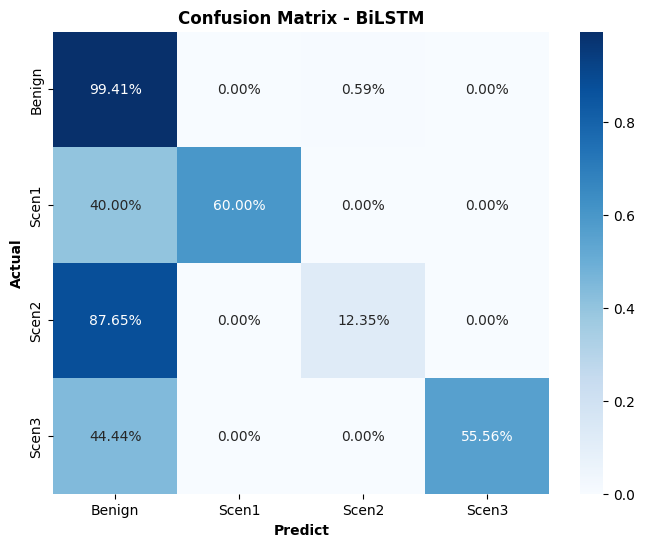

2026-04-09 15:11:26.777692: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



-> [MÀNG LỌC VỚT] Tầng 2 đã soi 89949 mẫu Benign và lôi cổ thêm được:
   + 2389 mẫu Scen2 ẩn mình (Ngưỡng 0.15)!

🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)
              precision    recall  f1-score   support

      Benign     0.9991    0.9685    0.9836     90321
       Scen1     0.9545    0.6000    0.7368        35
       Scen2     0.0333    0.6049    0.0632       162
       Scen3     1.0000    0.5556    0.7143         9

    accuracy                         0.9677     90527
   macro avg     0.7467    0.6823    0.6245     90527
weighted avg     0.9973    0.9677    0.9818     90527



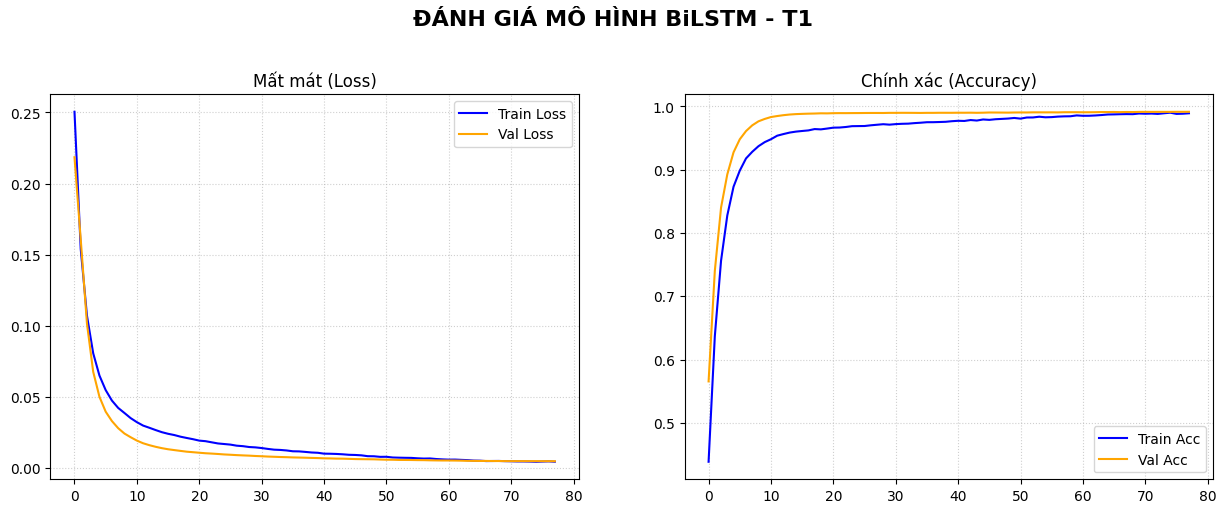

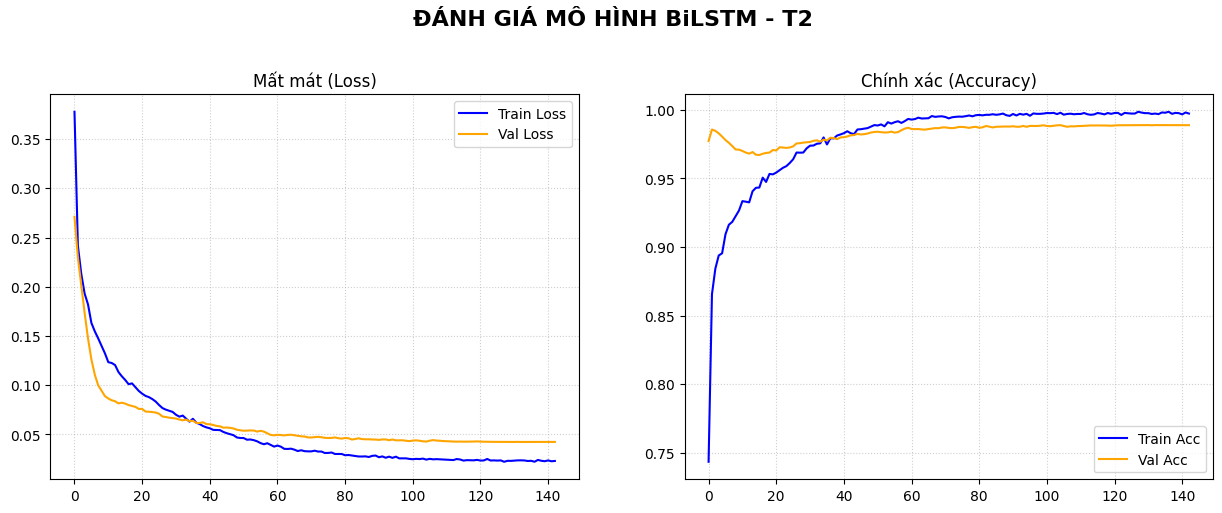

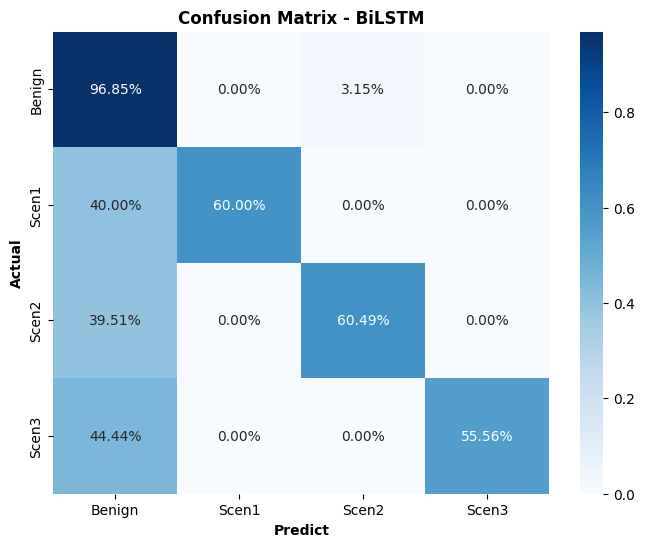

In [1]:
#BiLSTM Cân Bằng RUS+SMOTE có Temporal Feature
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
import time
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy, BinaryFocalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

# 🔒 HÀM CỐ ĐỊNH SEED BẮT BUỘC ĐỂ KẾT QUẢ KHÔNG NHẢY MÚA
def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()
    print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

set_all_seeds(42)
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# Đảm bảo dữ liệu được sắp xếp chuẩn xác theo thời gian
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))
    
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# XÓA CỘT ZERO VARIANCE
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3. PHÂN LOẠI (FREQUENCY SMOOTHING) & SCALE CHỌN LỌC
# ==============================================================================
print("\n[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...")

categorical_cols = ['pc','start_with', 'end_with', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# 1. Frequency Encoding (Có Smoothing)
for col in cat_cols_to_keep:
    freq_map_raw = df_train[col].value_counts(normalize=True).to_dict()
    freq_map = {k: max(v, 0.01) for k, v in freq_map_raw.items()}
    df_train[col] = df_train[col].map(freq_map).fillna(0.01)
    df_val[col]   = df_val[col].map(freq_map).fillna(0.01)
    df_test[col]  = df_test[col].map(freq_map).fillna(0.01)

# 2. CHỈ SCALE CỘT NUMERIC (Giữ nguyên Categorical)
scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

print(f" -> Đã ép {len(cat_cols_to_keep)} cột Categorical thành Tần suất.")
print(f" -> Đã Scale chuẩn hóa {len(num_cols_to_scale)} cột Numeric.")

# # ==============================================================================
# # 4. TẠO TEMPORAL FEATURES (VECTORIZED - SIÊU TỐC ĐỘ)
# # ==============================================================================
# print("\n[4/5] Đang tính toán Percentile và MeanDiff siêu tốc (Pandas Vectorization)...")

# def add_fast_temporal_features(df, features, window_size=5):
#     # Đảm bảo sort đúng thứ tự trước khi cuộn
#     df = df.sort_values(['user', 'starttime']).copy()
    
#     # Gom nhóm theo user để thực hiện rolling
#     grouped = df.groupby('user')[features]
    
#     # --- 1. TÍNH MEANDIFF ---
#     # Logic: Lấy trung bình của window_size dòng TRƯỚC ĐÓ (Dùng shift(1))
#     shifted_rolling_mean = grouped.shift(1).groupby(df['user']).rolling(window=window_size, min_periods=1).mean()
#     shifted_rolling_mean = shifted_rolling_mean.reset_index(level=0, drop=True).sort_index()
    
#     meandiff_df = df[features] - shifted_rolling_mean
#     meandiff_df = meandiff_df.fillna(0.0)
#     meandiff_df.columns = [f"{c}_meandiff" for c in features]
    
#     # --- 2. TÍNH PERCENTILE ---
#     # Logic: Dùng hàm rank(pct=True) của Pandas để thay thế percentileofscore.
#     # Nhân 100 và trừ 50 để ép về dải [-50, 50] chuẩn ý đồ của bạn.
#     # Cửa sổ lúc này là window_size + 1 (Bao gồm dòng hiện tại để so sánh thứ hạng)
#     pct_df = grouped.rolling(window_size + 1, min_periods=1).rank(pct=True)
#     #pct_df = grouped.shift(1).groupby(df['user']).rolling(window=window_size, min_periods=1).rank(pct=True)
#     pct_df = pct_df.reset_index(level=0, drop=True).sort_index()
#     pct_df = (pct_df * 100) - 50.0 
#     pct_df = pct_df.fillna(0.0)
#     pct_df.columns = [f"{c}_pct" for c in features]
    
#     # Nối song song lại với DataFrame gốc
#     return pd.concat([df, pct_df, meandiff_df], axis=1)

# # Áp dụng cho cả 3 tập
# df_train = add_fast_temporal_features(df_train, feature_cols, window_size=5)
# df_val   = add_fast_temporal_features(df_val, feature_cols, window_size=5)
# df_test  = add_fast_temporal_features(df_test, feature_cols, window_size=5)

# # Cập nhật lại kho Feature Cols (Gốc + Pct + MeanDiff)
# new_pct_cols = [f"{c}_pct" for c in feature_cols]
# new_md_cols = [f"{c}_meandiff" for c in feature_cols]
# final_feature_cols = feature_cols + new_pct_cols + new_md_cols

# print(" -> Đã gộp thành công Percentile + MeanDiff.")
# print(f" -> Tổng số cột chuẩn bị nạp vào Sliding Window: {len(final_feature_cols)}")
# ==============================================================================
# 4. TẠO TEMPORAL FEATURES CHỈ TRÊN CÁC CỘT CHỌN LỌC (VECTORIZED)
# ==============================================================================
print("\n[4/5] Đang tính toán Percentile và MeanDiff trên danh sách chọn lọc...")

# Danh sách các cột bạn muốn tính Temporal (Copy nguyên xi của bạn)
# temporal_feature_compute = [
#     'http_socnetf_mean_url_depth', 'file_mean_file_len', 'http_jobf_mean_url_len', 'n_usb', 'http_n_leakf', 'file_n_docf', 
#     'isafterhour', 'n_concurrent_sessions', 'http_leakf_mean_http_c_nwords', 'http_otherf_mean_http_c_nwords', 'usb_mean_usb_dur', 
#     'role', 'n_allact', 'ses_start', 'http_leakf_mean_http_c_len', 'f_unit', 'http_jobf_mean_url_depth', 'http_n_otherf', 
#     'http_leakf_mean_url_depth', 'email_mean_n_des', 'file_docf_n-disk0', 'n_file', 'n_http', 'http_jobf_mean_http_c_nwords', 
#     'duration', 'file_n-disk0', 'E', 'http_leakf_mean_url_len', 'http_mean_url_depth', 'end_with', 'http_hackf_mean_http_c_len', 
#     'http_jobf_mean_http_c_len', 'isworkhour', 'team', 'N', 'file_mean_file_nwords', 'http_n_hackf', 'A', 'http_mean_url_len',
#     'O', 'ses_end', 'dept', 'C', 'ITAdmin'
# ]
temporal_feature_compute= ['http_mean_http_c_len', 'http_n_cloudf', 'http_socnetf_mean_url_depth', 'file_mean_file_len', 
                           'http_cloudf_mean_url_len', 'http_jobf_mean_url_len', 'n_usb', 'http_n_leakf', 'file_n_docf', 
                           'isafterhour', 'n_concurrent_sessions', 'http_leakf_mean_http_c_nwords', 'http_otherf_mean_url_len', 
                           'http_otherf_mean_http_c_nwords', 'http_mean_http_c_nwords', 'http_socnetf_mean_url_len', 'usb_mean_usb_dur', 
                           'role', 'n_allact', 'ses_start', 'http_socnetf_mean_http_c_len', 'email_n-Xemail1', 'http_otherf_mean_http_c_len', 
                           'http_n_jobf', 'http_leakf_mean_http_c_len', 'f_unit', 'http_jobf_mean_url_depth', 'http_n_otherf', 
                           'http_leakf_mean_url_depth', 'email_mean_n_des', 'isweekendafterhour', 'file_docf_n-disk0', 'n_file',
                           'http_hackf_mean_url_depth', 'n_http', 'http_jobf_mean_http_c_nwords', 'email_mean_email_text_nwords', 
                           'duration', 'http_socnetf_mean_http_c_nwords', 'E', 'http_leakf_mean_url_len', 'http_mean_url_depth', 
                           'end_with', 'file_n-disk0', 'http_hackf_mean_http_c_len', 'http_hackf_mean_http_c_nwords', 'http_jobf_mean_http_c_len', 
                           'file_docf_mean_file_nwords', 'isworkhour', 'team', 'email_mean_email_size', 'http_otherf_mean_url_depth', 'n_days', 
                           'email_mean_email_text_slen', 'http_cloudf_mean_url_depth', 'http_hackf_mean_url_len', 'N', 'file_docf_mean_file_len', 
                           'file_mean_file_nwords', 'http_n_hackf', 'A', 'http_mean_url_len', 'O', 'ses_end', 'http_n_socnetf', 'dept', 'C', 'ITAdmin']
# 🔴 LỚP BẢO VỆ: Chỉ lấy những cột tồn tại trong feature_cols hiện tại 
# (Phòng trường hợp bị rớt lại ở bước xóa cột Zero-Variance)
valid_temporal_cols = [c for c in temporal_feature_compute if c in feature_cols]
print(f" -> Số lượng cột hợp lệ để tính Temporal: {len(valid_temporal_cols)}/{len(temporal_feature_compute)}")
def add_fast_temporal_features(df, features_to_compute, window_size=5):
    # Đảm bảo sort đúng thứ tự trước khi cuộn
    df = df.sort_values(['user', 'starttime']).copy()
    # Gom nhóm theo user để thực hiện rolling CHỈ trên các cột chọn lọc
    grouped = df.groupby('user')[features_to_compute]
    # --- 1. TÍNH MEANDIFF ---
    shifted_rolling_mean = grouped.shift(1).groupby(df['user']).rolling(window=window_size, min_periods=1).mean()
    shifted_rolling_mean = shifted_rolling_mean.reset_index(level=0, drop=True).sort_index()
    meandiff_df = df[features_to_compute] - shifted_rolling_mean
    meandiff_df = meandiff_df.fillna(0.0)
    meandiff_df.columns = [f"{c}_meandiff" for c in features_to_compute]
    # --- 2. TÍNH PERCENTILE ---
    pct_df = grouped.rolling(window_size + 1, min_periods=1).rank(pct=True)
    pct_df = pct_df.reset_index(level=0, drop=True).sort_index()
    pct_df = (pct_df * 100) - 50.0 
    pct_df = pct_df.fillna(0.0)
    pct_df.columns = [f"{c}_pct" for c in features_to_compute]
    # Nối song song lại với DataFrame gốc (Vẫn giữ nguyên 68 cột gốc ban đầu)
    return pd.concat([df, pct_df, meandiff_df], axis=1)
# Áp dụng cho cả 3 tập
df_train = add_fast_temporal_features(df_train, valid_temporal_cols, window_size=5)
df_val   = add_fast_temporal_features(df_val, valid_temporal_cols, window_size=5)
df_test  = add_fast_temporal_features(df_test, valid_temporal_cols, window_size=5)
# 🔴 CẬP NHẬT KHO ĐẶC TRƯNG CHUẨN XÁC
# Chỉ sinh ra cột mới dựa trên valid_temporal_cols, còn feature_cols (68 cột gốc) vẫn giữ nguyên!
new_pct_cols = [f"{c}_pct" for c in valid_temporal_cols]
new_md_cols = [f"{c}_meandiff" for c in valid_temporal_cols]

# Thay vì cộng với feature_cols (107 cột), ta chỉ lấy 44 cột đã chọn + 88 cột mới
final_feature_cols = valid_temporal_cols + new_pct_cols + new_md_cols

print("\n -> Đã gộp thành công Percentile + MeanDiff.")
print(f" -> Số cột Gốc được GIỮ LẠI: {len(valid_temporal_cols)}")
print(f" -> Số cột bị VỨT BỎ: {len(feature_cols) - len(valid_temporal_cols)}")
print(f" -> Số cột Mới thêm (Pct + MeanDiff): {len(new_pct_cols) + len(new_md_cols)}")
print(f" -> Tổng số cột chuẩn bị nạp vào Sliding Window: {len(final_feature_cols)} (Sẽ ra đúng 132 cột!)")

import numpy as np
import pandas as pd
from tqdm import tqdm
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import tensorflow as tf

# ==============================================================================
# 5. TẠO TENSOR 3D BẰNG SLIDING WINDOW 
# ==============================================================================
print("\n[5/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...")

# Phân tách danh sách cột rõ ràng để dễ xử lý về sau
raw_cols = [c for c in final_feature_cols if '_pct' not in c and '_meandiff' not in c]
temporal_cols = [c for c in final_feature_cols if '_pct' in c or '_meandiff' in c]

def create_sliding_windows_3D(df_subset, window_size=5, step=1):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        # Lấy toàn bộ features theo đúng thứ tự của final_feature_cols
        features = group[final_feature_cols].values
        labels = group['insider'].values
        for i in range(0, len(group) - window_size + 1, step):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
# Bạn có thể dùng step=2 ở tập Train nếu muốn chống Overfit mạnh hơn
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1) 
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1)

# ==============================================================================
# 🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (SMOTE CÓ CHỌN LỌC)
# ==============================================================================
print("\n" + "="*75)
print("🟢 XỬ LÝ MẤT CÂN BẰNG: SMOTE CHỈ TRÊN RAW FEATURES")
print("="*75)
N_train, T, F = X_train.shape
# 1. Đập phẳng Tensor 3D thành 2D để đưa vào thư viện imblearn
X_train_flat = X_train.reshape(N_train, T * F)
# 2. TÁCH DỮ LIỆU THÀNH 2 PHẦN
# Lưu ý: Mỗi cửa sổ T bước thời gian sẽ chứa lặp lại các cột. 
# Ta cần xác định đúng index của raw và temporal trong mảng phẳng.
raw_indices_flat = []
temporal_indices_flat = []
for t in range(T):
    for i, col in enumerate(final_feature_cols):
        flat_idx = t * F + i
        if col in raw_cols:
            raw_indices_flat.append(flat_idx)
        else:
            temporal_indices_flat.append(flat_idx)

# 3. UNDERSAMPLING TRÊN TOÀN BỘ (Dân thường không bị méo mó gì cả)
rus = RandomUnderSampler(sampling_strategy={0: 20000}, random_state=42)
X_res_flat, y_res = rus.fit_resample(X_train_flat, y_train)
# 4. CHIA MẢNG SAU KHI UNDERSAMPLE
X_res_raw = X_res_flat[:, raw_indices_flat]
X_res_temporal = X_res_flat[:, temporal_indices_flat]
# 5. ÁP DỤNG SMOTE CHỈ TRÊN PHẦN RAW FEATURES
# 🔴 Lời khuyên: Chỉ bơm lên 2000 hoặc 3000 để làm Data Augmentation. KHÔNG bơm lên 10000!
smote_main = SMOTE(sampling_strategy={1: 5000, 2: 5000, 3: 5000}, random_state=42, k_neighbors=2)
# Lấy lại index do SMOTE sinh ra để biết nó đẻ thêm dòng nào
X_main_raw, y_main_bal = smote_main.fit_resample(X_res_raw, y_res)
# 6. BÙ ĐẮP PHẦN TEMPORAL CHO CÁC MẪU DO SMOTE SINH RA
# Các mẫu gốc (từ 0 đến len(X_res_raw)) giữ nguyên Temporal của nó.
# Các mẫu mới sinh ra (từ len(X_res_raw) trở đi) sẽ được gán Temporal bằng 0 (Hoặc copy từ hàng xóm)
# Cách an toàn nhất: Gán 0 cho các giá trị Percentile/MeanDiff ảo để mô hình hiểu đây là nhiễu, 
# sau đó dùng Trọng số Lớp (Class Weights) để ép mô hình học bù lại.
num_original = len(X_res_raw)
num_total_bal = len(X_main_raw)
# Khởi tạo mảng temporal mới bằng 0
X_main_temporal = np.zeros((num_total_bal, len(temporal_indices_flat)))
# Copy nguyên vẹn temporal của các mẫu thật
X_main_temporal[:num_original, :] = X_res_temporal

# 7. GHÉP NỐI LẠI THÀNH MẢNG PHẲNG HOÀN CHỈNH
X_main_flat = np.zeros((num_total_bal, T * F))
X_main_flat[:, raw_indices_flat] = X_main_raw
X_main_flat[:, temporal_indices_flat] = X_main_temporal

# 8. UỐN LẠI THÀNH TENSOR 3D ĐỂ VÀO BiLSTM
X_train_main = X_main_flat.reshape(-1, T, F)

# Chuyển One-hot
y_main_bal_onehot = tf.keras.utils.to_categorical(y_main_bal, num_classes=4)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

print(f" -> Kích thước Tensor 3D cuối cùng (Train): {X_train_main.shape}")
start_time_t1 = time.time()
model_main = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(4, activation='softmax')
])
focal_loss_t1 = CategoricalFocalCrossentropy(
    gamma=1.0, 
    #alpha=[0.05, 0.15, 0.35, 0.25] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
)

model_main.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=focal_loss_t1, # 🔴 THAY CROSS-ENTROPY BẰNG FOCAL LOSS TẠI ĐÂY
    metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
)
# 🔴 ĐỔI LOSS SANG CATEGORICAL VÀ THÊM METRIC AUC
# model_main.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
#     loss='categorical_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
# )

es_main = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# es_main = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# rlr_main = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)

history_main = model_main.fit(
    X_train_main, y_main_bal_onehot, 
    validation_data=(X_val, y_val_onehot),
    epochs=100, batch_size=256, callbacks=[es_main, rlr_main], verbose=1
)
train_time_t1 = time.time() - start_time_t1

###############################################################
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (BINARY: BENIGN vs SCEN 2)")
print("="*75)
# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2)
# mask_train = (y_main_bal == 0) | (y_main_bal == 2)
# X_train_expert = X_train_main[mask_train]
# y_train_expert_raw = y_main_bal[mask_train]
# mask_val = (y_val == 0) | (y_val == 2)
# X_val_expert = X_val[mask_val]
# y_val_expert_raw = y_val[mask_val]
# # 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
# # 🔴 LƯU Ý: Đã làm Nhị phân thì KHÔNG CẦN One-Hot Encoding nữa!
# y_train_expert = np.where(y_train_expert_raw == 2, 1, 0)
# y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2 - CÂN BẰNG 1:1)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (CÂN BẰNG TUYỆT ĐỐI 1:1)")
print("="*75)
# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2 từ tập Train cân bằng của T1)
mask_train = (y_main_bal == 0) | (y_main_bal == 2)
X_train_expert_raw = X_train_main[mask_train]
y_train_expert_raw = y_main_bal[mask_train]
mask_val = (y_val == 0) | (y_val == 2)
X_val_expert = X_val[mask_val]
y_val_expert_raw = y_val[mask_val]
# 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
y_train_expert_bin = np.where(y_train_expert_raw == 2, 1, 0)
y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ====================================================================
# 🔴 3. BÍ KÍP ÉP TỶ LỆ 1:1 CHO TẬP TRAIN TẦNG 2
# ====================================================================
print("-> Đang xén bớt Benign để ép tỷ lệ 1:1 cho Tầng 2...")
# Lấy ra index của từng nhóm
idx_benign = np.where(y_train_expert_bin == 0)[0]
idx_scen2 = np.where(y_train_expert_bin == 1)[0]
# Đếm số lượng của Scen 2 (Nhóm thiểu số)
num_scen2 = len(idx_scen2)
# Bốc ngẫu nhiên Benign sao cho số lượng vừa bằng đúng Scen 2
np.random.seed(42) # Khóa Seed cho chắc cú
idx_benign_downsampled = np.random.choice(idx_benign, size=num_scen2, replace=False)
# Gom 2 nhóm index lại và xáo trộn lên (Shuffle)
idx_balanced = np.concatenate([idx_benign_downsampled, idx_scen2])
np.random.shuffle(idx_balanced)
# Tạo ra tập Train Tầng 2 MỚI, CHUẨN, VÀ CÂN BẰNG 1:1
X_train_expert = X_train_expert_raw[idx_balanced]
y_train_expert = y_train_expert_bin[idx_balanced]
print(f"✅ Đã cân bằng xong! Phân bổ Train Tầng 2: {dict(zip(*np.unique(y_train_expert, return_counts=True)))}")

start_time_t2 = time.time()
model_expert = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(T, F)),
    Dropout(0.5), 
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    # 🔴 Đã lùi về 1 Nơ-ron với hàm Sigmoid (Chuyên trị Nhị phân)
    Dense(1, activation='sigmoid') 
])
# 3. ÁP DỤNG BINARY FOCAL LOSS
focal_loss_binary = BinaryFocalCrossentropy(
    gamma=1.0, 
    #apply_class_balancing=True 
    #alpha=0.85 
)
model_expert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=focal_loss_binary, 
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] # Bỏ multi_label đi
)
# model_expert.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
#     loss='binary_crossentropy', 
#     metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] # Bỏ multi_label đi
# )
# es_expert = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
# rlr_expert = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
print("\n🚀 BẮT ĐẦU TRAINING TẦNG 2 (SALVAGE NET)...")
history_expert = model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert),
    epochs=150, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET S1, S2 & S3)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt Toàn Diện...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
probs_main = model_main.predict(X_test, verbose=0)
preds_main = np.argmax(probs_main, axis=1)
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4, zero_division=0))

cm_final_t1 = confusion_matrix(y_test, preds_main)
cmn_final_t1 = cm_final_t1.astype('float') / cm_final_t1.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final_t1, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - BiLSTM', fontweight='bold')
plt.show()

# --- MÀNG LỌC VỚT TẦNG 2 CHO SCEN 2 & SCEN 3 ---
final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] # Trích xuất nhóm bị phán Benign
############################################################################################
############################################################################################
if len(review_idx) > 0:
    # probs_expert lúc này là mảng 2D shape (N, 1) chứa tỷ lệ % là Scen 2
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # Ép phẳng về mảng 1D (N,) cho dễ tính toán
    probs_scen2 = probs_expert.flatten()
    # 🔴 ĐẶT NGƯỠNG VỚT CHO SCEN 2 (Tùy chỉnh 0.15 - 0.3)
    THRESHOLD_SCEN2 = 0.15  
    # Tìm những đứa vượt ngưỡng
    is_scen2 = probs_scen2 >= THRESHOLD_SCEN2
    # Cập nhật mảng kết quả
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    # Đè lên mảng final_preds gốc
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")
############################################################################################
# Phía dưới này bạn cứ giữ nguyên phần code vẽ Biểu đồ và In CM của tui lúc trước nhé!
# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ (NÂNG CẤP VỚI AUC)
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
fig1.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T1', fontsize=16, fontweight='bold', y=1.05)

axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('Mất mát (Loss)')
axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)

axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('Chính xác (Accuracy)')
axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)

# axes1[2].plot(history_main.history['auc'], label='Train AUC', color='blue')
# axes1[2].plot(history_main.history['val_auc'], label='Val AUC', color='orange')
# axes1[2].set_title('Diện tích dưới đường cong (AUC)')
# axes1[2].legend(); axes1[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle('ĐÁNH GIÁ MÔ HÌNH BiLSTM - T2', fontsize=16, fontweight='bold', y=1.05)

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('Mất mát (Loss)')
axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('Chính xác (Accuracy)')
axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)

# axes2[2].plot(history_expert.history['auc'], label='Train AUC', color='green')
# axes2[2].plot(history_expert.history['val_auc'], label='Val AUC', color='red')
# axes2[2].set_title('Diện tích dưới đường cong (AUC)')
# axes2[2].legend(); axes2[2].grid(True, linestyle='--', alpha=0.6)
plt.show()

# MA TRẬN NHẦM LẪN
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix - BiLSTM', fontweight='bold')
plt.show()